## Ignore Warnings About Deprecated Features (for HuggingFace)

In [1]:
import warnings

In [5]:
warnings.filterwarnings("ignore", category=FutureWarning)

## Import Necessary Libraries

In [3]:
import os
import re
import json
import spacy
import textstat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import NMF, TruncatedSVD
from sentence_transformers import SentenceTransformer
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.model_selection import StratifiedGroupKFold

C:\Users\kolia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helpers

In [6]:
def clean_function(text):
    # --- 1. Remove photo captions like (Photo by ... /Getty Images) ---
    text = re.sub(r"\(photo by.*?\)", " ", text, flags=re.IGNORECASE)

    # --- 2. Remove common image credit terms ---
    text = re.sub(r"\b(getty images|getty|photo|image|credit|caption)\b", " ", text, flags=re.IGNORECASE)

    # --- 3. Remove known outlet names (EDIT THIS LIST) ---
    outlet_patterns = [
        r"\b(the\s+)?daily\s+beast\b",
        r"\bmother\s+jones\b",
        r"\balternet\b",
        r"\bcounter\s*punch\b",
        r"\bsalon\b",
        r"\b(the\s+)?american\s+conservative\b",
        r"\b(the\s+)?american\s+spectator\b",
        r"\b(the\s+)?daily\s+caller\b",
        r"\b(the\s+)?washington\s+free\s+beacon\b",
        r"\bfree\s+beacon\b",
        r"\bfox\s+news\b",
        r"\bdigital\b",
    ]
    
    for pattern in outlet_patterns:
        text = re.sub(rf"\b{pattern}\b", " ", text, flags=re.IGNORECASE)

    # --- 4. Remove generic publishing artifacts ---
    text = re.sub(r"\b(news digital|subscribe|newsletter|click here)\b", " ", text, flags=re.IGNORECASE)

    # --- 5. Remove extra whitespace ---
    text = re.sub(r"\s+", " ", text).strip()

    return text

## Initialise File Locations

In [7]:
file_paths = {"AlterNet": os.getcwd() + "\\articles\\left\\alter-net\\",
             "CounterPunch": os.getcwd() + "\\articles\\left\\counter-punch\\",
             "DailyBeast": os.getcwd() + "\\articles\\left\\daily-beast\\",
             "MotherJones": os.getcwd() + "\\articles\\left\\mother-jones\\",
             "Salon": os.getcwd() + "\\articles\\left\\salon\\",
             "American_Conservative": os.getcwd() + "\\articles\\right\\american-conservative\\",
             "American_Spectator": os.getcwd() + "\\articles\\right\\american-spectator\\",
             "DailyCaller": os.getcwd() + "\\articles\\right\\daily-caller\\",
             "FoxNews": os.getcwd() + "\\articles\\right\\fox-news\\",
             "The_Free_Beacon": os.getcwd() + "\\articles\\right\\the-free-beacon\\"}

## Import and Format JSON into Pandas DataFrames

In [8]:
path_file_alternet = file_paths["AlterNet"]+"alternet_200_articles.json"
with open(path_file_alternet, 'r', encoding='utf-8') as file:
    alternet = json.load(file)

df_alternet = pd.DataFrame(pd.json_normalize(alternet))
df_alternet = df_alternet.rename(columns={"headline": "title", "body_text": "text", "body_word_count": "word_count", "outlet": "source"})
df_alternet = df_alternet.iloc[:, [0, 5, 6, 3, 1, 4, 7, 8]]
df_alternet = df_alternet.drop(columns=["url", "processed_at"])

In [9]:
path_file_counterpunch = file_paths["CounterPunch"]+"counterpunch_200_articles.json"
with open(path_file_counterpunch, 'r', encoding='utf-8') as file:
    counterpunch = json.load(file)

df_counterpunch = pd.DataFrame(pd.json_normalize(counterpunch))
df_counterpunch = df_counterpunch.rename(columns={"headline": "title", "body": "text", "outlet name": "source"})
df_counterpunch = df_counterpunch.iloc[:, [0, 8, 6, 4, 2, 5, 1, 7, 3]]
df_counterpunch = df_counterpunch.drop(columns=["url", "crawl_timestamp", "publishing_date"])

In [10]:
path_file_DailyBeast = file_paths["DailyBeast"]+"dailybeast_200_articles.json"
with open(path_file_DailyBeast, 'r', encoding='utf-8') as file:
    DailyBeast = json.load(file)

df_DailyBeast = pd.DataFrame(pd.json_normalize(DailyBeast))
df_DailyBeast = df_DailyBeast.rename(columns={"id": "article_id", "headline": "title", "body": "text"})
df_DailyBeast["source"] = "DailyBeast"
df_DailyBeast["label"] = "left"
df_DailyBeast = df_DailyBeast.iloc[:, [0, 7, 8, 4, 2, 5, 1, 3]]
df_DailyBeast = df_DailyBeast.drop(columns=["url", "published_datetime_raw"])

In [11]:
path_file_MotherJones = file_paths["MotherJones"]+"mother_jones_articles.json"
with open(path_file_MotherJones, 'r', encoding='utf-8') as file:
    MotherJones = json.load(file)

df_MotherJones = pd.DataFrame(pd.json_normalize(MotherJones))
df_MotherJones = df_MotherJones.rename(columns={"header": "title", "body_text": "text", "outlet": "source"})
df_MotherJones = df_MotherJones.iloc[:, [0, 4, 5, 2, 1, 3, 6, 7]]
df_MotherJones = df_MotherJones.drop(columns=["url", "published_date"])

In [12]:
path_file_Salon = file_paths["Salon"]+"salon_articles.json"
with open(path_file_Salon, 'r', encoding='utf-8') as file:
    Salon = json.load(file)

df_Salon = pd.DataFrame(pd.json_normalize(Salon))
df_Salon = df_Salon.rename(columns={"header": "title", "body_text": "text", "outlet": "source"})
df_Salon = df_Salon.iloc[:, [0, 4, 8, 2, 1, 3, 5, 6]]
df_Salon = df_Salon.drop(columns=["url", "published_date"])

In [13]:
path_file_American_Conservative = file_paths["American_Conservative"]+"the_american_conservative_200_articles_20260410_231549.json"
with open(path_file_American_Conservative, 'r', encoding='utf-8') as file:
    American_Conservative = json.load(file)

df_American_Conservative = pd.DataFrame(pd.json_normalize(American_Conservative))
df_American_Conservative = df_American_Conservative.rename(columns={"headline": "title", "body_text": "text", "outlet_name": "source"})
df_American_Conservative = df_American_Conservative.iloc[:, [0, 5, 7, 3, 2, 6, 8, 4, 1]]
df_American_Conservative = df_American_Conservative.drop(columns=["url", "publication_date", "crawl_timestamp"])

In [14]:
path_file_American_Spectator = file_paths["American_Spectator"]+"spectator_articles.json"
with open(path_file_American_Spectator, 'r', encoding='utf-8') as file:
    American_Spectator = json.load(file)

df_American_Spectator = pd.DataFrame(pd.json_normalize(American_Spectator))
df_American_Spectator = df_American_Spectator.rename(columns={"headline": "title", "body_text": "text", "outlet_name": "source"})
df_American_Spectator = df_American_Spectator.iloc[:, [0, 5, 7, 2, 1, 6, 3, 8, 4]]
df_American_Spectator = df_American_Spectator.drop(columns=["url", "publication_date", "crawl_time"])

In [15]:
path_file_DailyCaller = file_paths["DailyCaller"]+"dailycaller_200_articles.json"
with open(path_file_DailyCaller, 'r', encoding='utf-8') as file:
    DailyCaller = json.load(file)

df_DailyCaller = pd.DataFrame(pd.json_normalize(DailyCaller))
df_DailyCaller = df_DailyCaller.rename(columns={"id":"article_id", "headline": "title", "body": "text", "outlet": "source"})
df_DailyCaller = df_DailyCaller.iloc[:, [0, 9, 7, 5, 2, 6, 1, 3, 4, 8]]
df_DailyCaller = df_DailyCaller.drop(columns=["url", "published", "published_raw", "crawl_timestamp"])

In [16]:
path_file_FoxNews = file_paths["FoxNews"]+"foxnews_200_articles.json"
with open(path_file_FoxNews, 'r', encoding='utf-8') as file:
    FoxNews = json.load(file)

df_FoxNews = pd.DataFrame(pd.json_normalize(FoxNews))
df_FoxNews = df_FoxNews.rename(columns={"headline": "title", "body_text": "text", "outlet": "source", "body_word_count": "word_count"})
df_FoxNews = df_FoxNews.iloc[:, [0, 4, 5, 2, 1, 3, 6, 7, 8]]
df_FoxNews = df_FoxNews.drop(columns=["url", "publication_datetime", "crawl_timestamp"])

In [17]:
path_file_The_Free_Beacon = file_paths["The_Free_Beacon"]+"freebeacon_articles.json"
with open(path_file_The_Free_Beacon, 'r', encoding='utf-8') as file:
    The_Free_Beacon = json.load(file)

df_The_Free_Beacon = pd.DataFrame(pd.json_normalize(The_Free_Beacon))
df_The_Free_Beacon = df_The_Free_Beacon.rename(columns={"headline": "title", "main_body": "text", "outlet": "source"})
df_The_Free_Beacon = df_The_Free_Beacon.iloc[:, [4, 6, 7, 2, 0, 5, 1, 3, 8]]
df_The_Free_Beacon = df_The_Free_Beacon.drop(columns=["url", "date_published", "crawl_timestamp"])

## Combine DataFrames and Encode Labels.

### Left => 0; Right => 1

In [18]:
df_list = [df_alternet, df_counterpunch, df_DailyBeast, df_MotherJones, df_Salon,
           df_American_Conservative, df_American_Spectator, df_DailyCaller, df_FoxNews, df_The_Free_Beacon]

df_final = pd.concat(df_list, axis=0)

In [19]:
df_final.loc[df_final['label']=="left", 'label'] = 0
df_final.loc[df_final['label']=="right", 'label'] = 1

In [20]:
df_final['label'].value_counts()

label
1    1000
0     999
Name: count, dtype: int64

## Clean and Prepare Texts

In [21]:
texts = df_final['text'].apply(clean_function).values
y = df_final['label'].astype(int).values
groups = df_final['source'].astype(str).str.strip().values

print("Texts: ", len(texts))
print("Labels: ", len(y))
print("Unique sources: ", len(groups))

Texts:  1999
Labels:  1999
Unique sources:  1999


## Initialise NLP Tools

In [22]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
sia = SentimentIntensityAnalyzer()
model_emb = SentenceTransformer('all-MiniLM-L6-v2')

## Batch Feature Helpers

In [23]:
def extract_pos_features_batch(texts):
    features = []

    for text in texts:
        doc = nlp(text)
        total_tokens = 0
        noun = verb = adj = adv = pron = modal = 0

        for token in doc:
            if token.is_punct or token.is_space:
                continue

            total_tokens += 1

            if token.pos_ == "NOUN": noun += 1
            elif token.pos_ == "VERB": verb += 1
            elif token.pos_ == "ADJ": adj += 1
            elif token.pos_ == "ADV": adv += 1
            elif token.pos_ == "PRON": pron += 1

            if token.lemma_.lower() in {"must", "should", "may", "might", "could", "would", "can"}:
                modal += 1
        if total_tokens == 0:
            features.append([0]*6)

        else:
            features.append([
                noun/total_tokens,
                verb/total_tokens,
                adj/total_tokens,
                adv/total_tokens,
                pron/total_tokens,
                modal/total_tokens
            ])
    
    return np.array(features)

In [24]:
def extract_sentiment_batch(texts):
    return np.array([
        [
            s["neg"], s["neu"], s["pos"], s["compound"]
        ] for s in (sia.polarity_scores(t[:1000]) for t in texts)
    ])

In [25]:
def extract_readability_batch(texts):
    return np.array([
        [
            textstat.flesch_reading_ease(t),
            textstat.flesch_kincaid_grade(t),
            textstat.gunning_fog(t),
            textstat.smog_index(t),
            textstat.automated_readability_index(t),
            textstat.words_per_sentence(t)
        ]
        for t in texts
    ])

## Builder Functions

In [26]:
def build_tfidf(train_text, test_text):
    
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30000,
        min_df=3,
        max_df=0.85,
        stop_words="english"
    )

    return vectorizer.fit_transform(train_text), vectorizer.transform(test_text)

In [27]:
def build_tfidf_nmf(train_text, test_text):
    
    X_train_tf, X_test_tf = build_tfidf(train_text, test_text)

    nmf = NMF(n_components = 20, random_state = 42, max_iter = 500)
    
    W_train = nmf.fit_transform(X_train_tf)
    W_test = nmf.transform(X_test_tf)

    return hstack([X_train_tf, W_train]), hstack([X_test_tf, W_test])

In [28]:
def build_full(train_text, test_text):

    X_train_tf, X_test_tf = build_tfidf(train_text, test_text)

    X_train_extra = np.hstack([
        extract_pos_features_batch(train_text),
        extract_sentiment_batch(train_text),
        extract_readability_batch(train_text)
    ])

    X_test_extra = np.hstack([
        extract_pos_features_batch(test_text),
        extract_sentiment_batch(test_text),
        extract_readability_batch(test_text)
    ])

    scaler = StandardScaler()
    X_train_extra = scaler.fit_transform(X_train_extra)
    X_test_extra = scaler.transform(X_test_extra)

    return (
        hstack([X_train_tf, csr_matrix(X_train_extra)]),
        hstack([X_test_tf, csr_matrix(X_test_extra)])
    )

In [29]:
def build_embeddings(train_text, test_text):
    return (
        model_emb.encode(list(train_text), show_progress_bar=False),
        model_emb.encode(list(test_text), show_progress_bar=False)
    )

In [30]:
def chunk_text(text, size=200):
    words = text.split()
    return [" ".join(words[i:i+size]) for i in range(0, len(words), size)]

def embed_document(text):
    chunks = chunk_text(text)
    emb = model_emb.encode(chunks, show_progress_bar=False)
    return np.mean(emb, axis=0)

def build_chunked(train_text, test_text):
    return (
        np.array([embed_document(t) for t in train_text]),
        np.array([embed_document(t) for t in test_text])
    )

## Run Function (Main)

In [33]:
def safe_counts(y):
    counts = np.bincount(y, minlength=2)
    return counts[0], counts[1]
    
def run_model(builder, name):

    gkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    fold_results = []
    cms_lr = []
    cms_svc = []

    print(f"\n===== {name} =====")

    for fold, (train_idx, test_idx) in enumerate(gkf.split(texts, y, groups)):

        X_train_text = texts[train_idx]
        X_test_text = texts[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        train_sources = np.unique(groups[train_idx])
        test_sources = np.unique(groups[test_idx])

        # --- features ---
        X_train, X_test = builder(X_train_text, X_test_text)

        # --- Logistic Regression ---
        lr = LogisticRegression(max_iter=2000)
        lr.fit(X_train, y_train)
        y_pred_lr = lr.predict(X_test)

        # --- SVC ---
        svc = LinearSVC(max_iter=20000)
        svc.fit(X_train, y_train)
        y_pred_svc = svc.predict(X_test)

        # --- Articles ---
        train_left, train_right = safe_counts(y_train)
        test_left, test_right = safe_counts(y_test)
        
        # --- metrics ---
        acc_lr = accuracy_score(y_test, y_pred_lr)
        acc_svc = accuracy_score(y_test, y_pred_svc)

        cm_lr = confusion_matrix(y_test, y_pred_lr, labels = [0, 1])
        cm_svc = confusion_matrix(y_test, y_pred_svc, labels = [0, 1])

        cms_lr.append(cm_lr)
        cms_svc.append(cm_svc)

        fold_results.append({
            "Model": name,
            "Fold": fold + 1,
            "LR Accuracy": acc_lr,
            "SVC Accuracy": acc_svc,
            "Train Size": len(train_idx),
            "Test Size": len(test_idx),
            "Train Left": train_left,
            "Train Right": train_right,
            "Test Left": test_left,
            "Test Right": test_right,
            "Train Sources": ", ".join(train_sources),
            "Test Sources": ", ".join(test_sources)
        })

        print(f"Fold {fold+1}: LR={acc_lr:.3f}, SVC={acc_svc:.3f}")

    # --- aggregate ---
    lr_scores = [f["LR Accuracy"] for f in fold_results]
    svc_scores = [f["SVC Accuracy"] for f in fold_results]

    summary = {
        "Model": name,
        "LR Mean": np.mean(lr_scores),
        "LR Std": np.std(lr_scores),
        "SVC Mean": np.mean(svc_scores),
        "SVC Std": np.std(svc_scores)
    }

    return fold_results, summary, cms_lr, cms_svc

## Run Experiments

In [34]:
experiments = [
    ("TF-IDF", build_tfidf),
    ("TF-IDF + NMF", build_tfidf_nmf),
    ("Full Linguistic", build_full),
    ("Embeddings", build_embeddings),
    ("Chunked Embeddings", build_chunked),
]

results = []

all_folds = []
summaries = []
all_cms_lr = {}
all_cms_svc = {}

for name, builder in experiments:
    fold_res, summary, cms_lr, cms_svc = run_model(builder, name)

    all_folds.extend(fold_res)
    summaries.append(summary)

    all_cms_lr[name] = cms_lr
    all_cms_svc[name] = cms_svc


===== TF-IDF =====
Fold 1: LR=0.767, SVC=0.782
Fold 2: LR=0.565, SVC=0.608
Fold 3: LR=0.115, SVC=0.230
Fold 4: LR=0.338, SVC=0.517
Fold 5: LR=0.779, SVC=0.774

===== TF-IDF + NMF =====
Fold 1: LR=0.772, SVC=0.780
Fold 2: LR=0.562, SVC=0.608
Fold 3: LR=0.128, SVC=0.233
Fold 4: LR=0.345, SVC=0.530
Fold 5: LR=0.784, SVC=0.779

===== Full Linguistic =====
Fold 1: LR=0.630, SVC=0.713
Fold 2: LR=0.550, SVC=0.603
Fold 3: LR=0.150, SVC=0.240
Fold 4: LR=0.360, SVC=0.530
Fold 5: LR=0.664, SVC=0.727

===== Embeddings =====
Fold 1: LR=0.675, SVC=0.667
Fold 2: LR=0.490, SVC=0.500
Fold 3: LR=0.230, SVC=0.315
Fold 4: LR=0.328, SVC=0.407
Fold 5: LR=0.649, SVC=0.614

===== Chunked Embeddings =====
Fold 1: LR=0.680, SVC=0.695
Fold 2: LR=0.545, SVC=0.555
Fold 3: LR=0.228, SVC=0.335
Fold 4: LR=0.352, SVC=0.420
Fold 5: LR=0.664, SVC=0.649


In [35]:
df_summary = pd.DataFrame(summaries)
df_summary = df_summary.sort_values(by="SVC Mean", ascending=False)

df_summary

,Model,LR Mean,LR Std,SVC Mean,SVC Std
1,TF-IDF + NMF,0.518392,0.253050,0.585890,0.201801
0,TF-IDF,0.512890,0.255997,0.582387,0.202951
2,Full Linguistic,0.470832,0.191935,0.562363,0.176727
4,Chunked Embeddings,0.493832,0.177311,0.530825,0.135766
3,Embeddings,0.474325,0.174541,0.500807,0.129490


In [36]:
df_folds = pd.DataFrame(all_folds)

df_folds.head()

,Model,Fold,LR Accuracy,SVC Accuracy,Train Size,Test Size,Train Left,Train Right,Test Left,Test Right,Train Sources,Test Sources
0,TF-IDF,1,0.767500,0.782500,1599,400,799,800,200,200,"CounterPunch, DailyBeast, Fox News, Mother Jon...","AlterNet, The American Spectator"
1,TF-IDF,2,0.565000,0.607500,1599,400,799,800,200,200,"AlterNet, DailyBeast, Fox News, Mother Jones, ...","CounterPunch, The American Conservative"
2,TF-IDF,3,0.115000,0.230000,1599,400,999,600,0,400,"AlterNet, CounterPunch, DailyBeast, Mother Jon...","Fox News, The Daily Caller"
3,TF-IDF,4,0.337500,0.517500,1599,400,599,1000,400,0,"AlterNet, CounterPunch, Fox News, Salon, The A...","DailyBeast, Mother Jones"
4,TF-IDF,5,0.779449,0.774436,1600,399,800,800,199,200,"AlterNet, CounterPunch, DailyBeast, Fox News, ...","Salon, The Washington Free Beacon"


In [37]:
def aggregate_cm(cms):
    return np.sum(cms, axis=0)

In [38]:
def plot_cm(cm, title):

    labels = ["Left", "Right"]

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

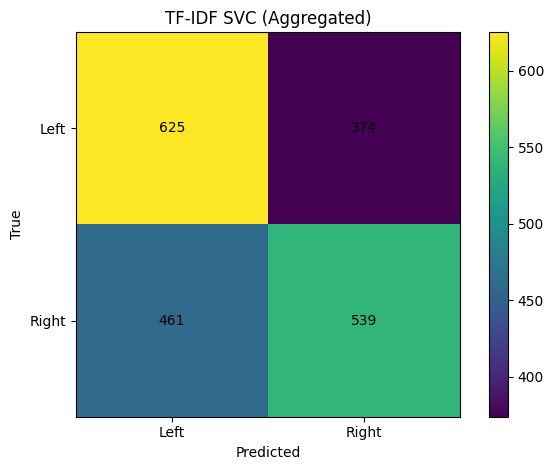

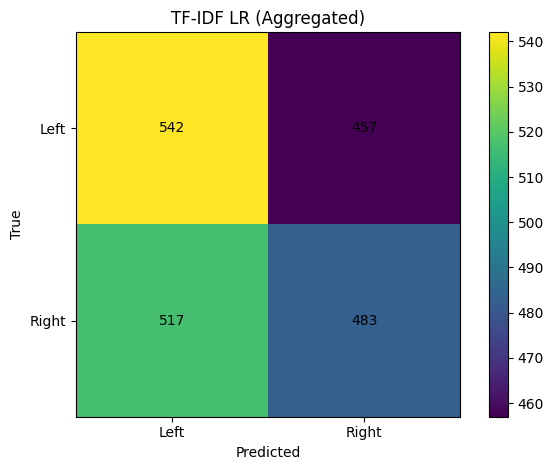

In [39]:
cm_tfidf_svc = aggregate_cm(all_cms_svc["TF-IDF"])
plot_cm(cm_tfidf_svc, "TF-IDF SVC (Aggregated)")
cm_tfidf_lr = aggregate_cm(all_cms_lr["TF-IDF"])
plot_cm(cm_tfidf_lr, "TF-IDF LR (Aggregated)")

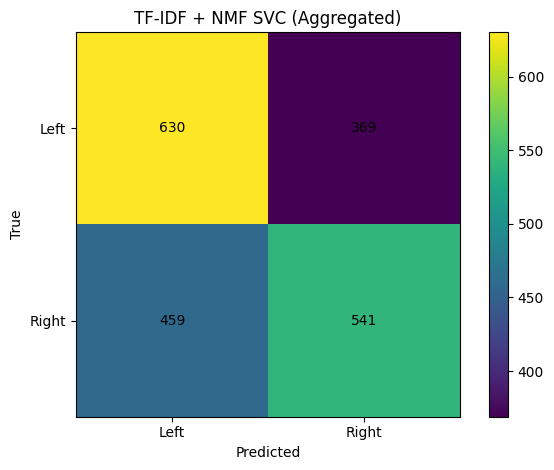

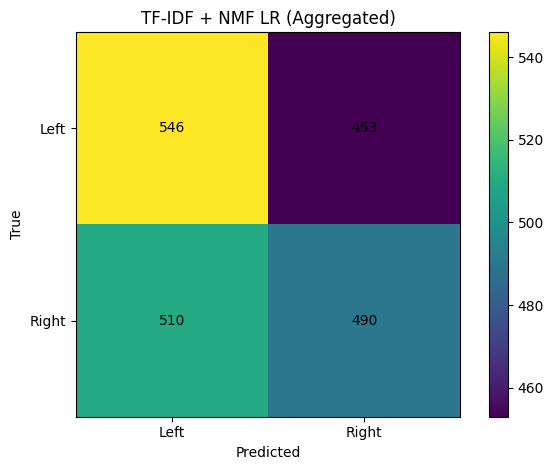

In [40]:
cm_tfidf_nmf_svc = aggregate_cm(all_cms_svc["TF-IDF + NMF"])
plot_cm(cm_tfidf_nmf_svc, "TF-IDF + NMF SVC (Aggregated)")
cm_tfidf_nmf_lr = aggregate_cm(all_cms_lr["TF-IDF + NMF"])
plot_cm(cm_tfidf_nmf_lr, "TF-IDF + NMF LR (Aggregated)")

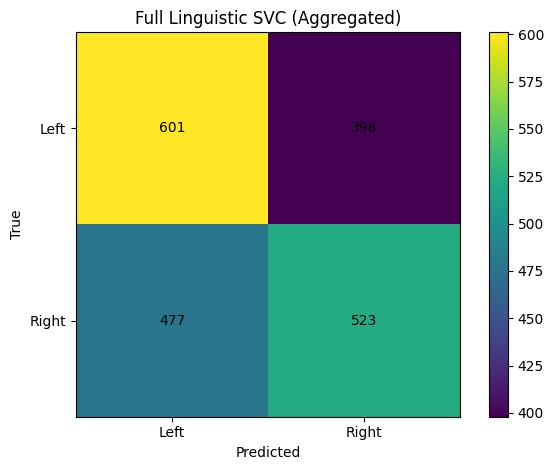

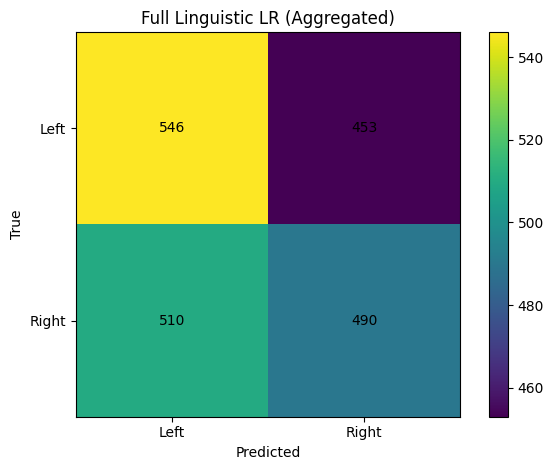

In [41]:
cm_full_linguistic_svc = aggregate_cm(all_cms_svc["Full Linguistic"])
plot_cm(cm_full_linguistic_svc, "Full Linguistic SVC (Aggregated)")
cm_full_linguistic_lr = aggregate_cm(all_cms_lr["TF-IDF + NMF"])
plot_cm(cm_full_linguistic_lr, "Full Linguistic LR (Aggregated)")

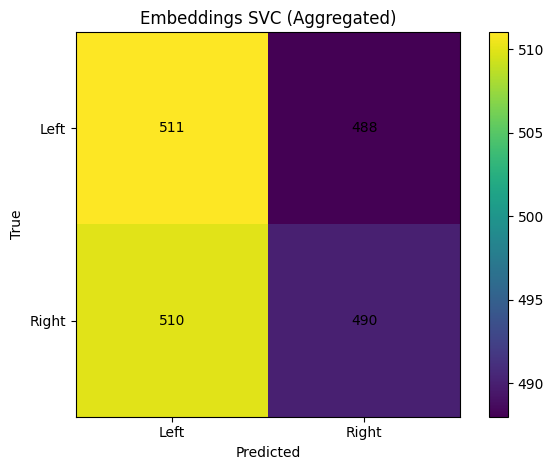

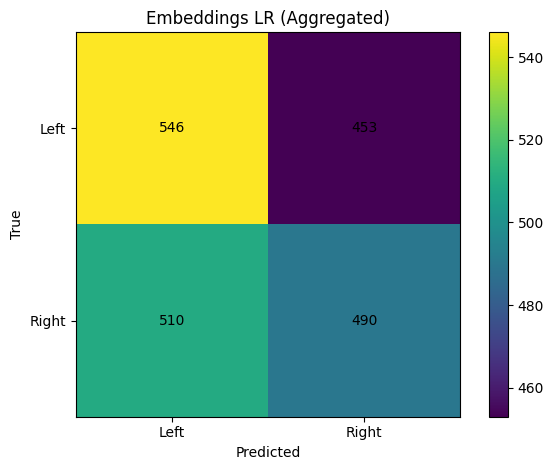

In [42]:
cm_embeddings_svc = aggregate_cm(all_cms_svc["Embeddings"])
plot_cm(cm_embeddings_svc, "Embeddings SVC (Aggregated)")
cm_embeddings_lr = aggregate_cm(all_cms_lr["TF-IDF + NMF"])
plot_cm(cm_embeddings_lr, "Embeddings LR (Aggregated)")

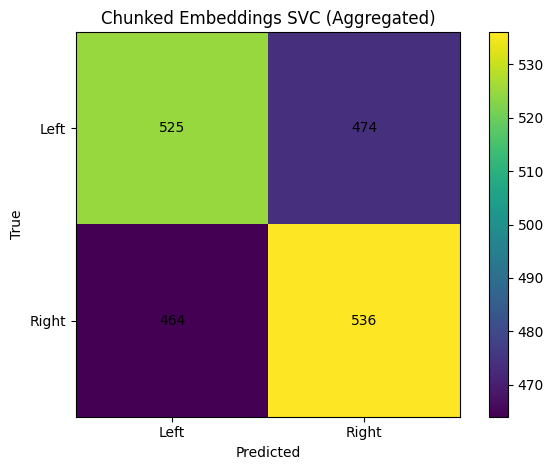

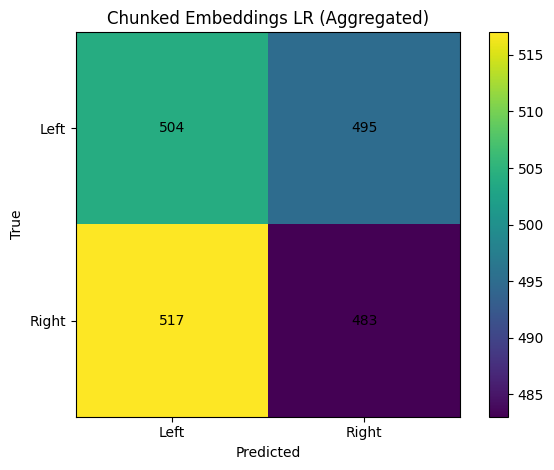

In [43]:
cm_chunked_embeddings_svc = aggregate_cm(all_cms_svc["Chunked Embeddings"])
plot_cm(cm_chunked_embeddings_svc, "Chunked Embeddings SVC (Aggregated)")
cm_chunked_embeddings_lr = aggregate_cm(all_cms_lr["Chunked Embeddings"])
plot_cm(cm_chunked_embeddings_lr, "Chunked Embeddings LR (Aggregated)")